# DINOv3 ViT-L/16 — Unfolded-Attention CRP Walkthrough

End-to-end concept attribution + relevance maximisation on DINOv3
ViT-L/16 with the unfolded-attention refactor and the AlphaBeta
(0.5, 0.5) bilinear rule. Mirrors the structure of the legacy
`tutorials/vit_crp/walkthrough.ipynb` but uses the new concept
classes (`HeadConcept`, `QConcept`, `KConcept`, `VConcept`,
`AttnOutputDimConcept`, `RegisterTokenConcept`).

**Choose your dataset** in section 2. Each option auto-downloads
and sets up everything on first use; you don't have to do any
manual setup. Available datasets:

* `funny_birds` — synthetic birds with ground-truth part maps
  (Hesse et al. ICCV 2023, arXiv:2308.06248). 50 classes,
  ~22k train + ~7k test. Auto-downloads ~1.5 GB zip from the
  TU Darmstadt mirror. **Recommended** for explainability work:
  small, simple, and the part maps let you verify whether
  attribution lights up the *correct* parts.
* `dsprites` — 2D shapes (square / ellipse / heart) with
  controlled latent factors (Higgins et al. ICLR 2017).
  Auto-downloads ~26 MB npz. Smallest synthetic option.
* `imagenet_val_hf` — full ImageNet-1k val (50k images, 1000
  classes) via the un-gated `evanarlian/imagenet_1k_resized_256`
  HuggingFace mirror (~830 MB).
* `imagenette` — fast.ai's 10-class ImageNet subset, ~98 MB.

**Train your own classifier head** for any of these datasets via:

```
uv run python experiments/train_dinov3_probe.py \
    --dataset {funny_birds | dsprites | imagenet_val_hf | imagenette} \
    --epochs 5 \
    --out data/vit_large_patch16_dinov3_probe_<dataset>.pt
```

The notebook below picks one dataset (default: `funny_birds`),
trains/loads the matching probe, and runs all the concept atlases
against that dataset's class space.

**Notebook structure:**

1. Setup
2. Configuration (composite + concept selection)
3. Layer name reference (which submodules are hookable)
4. Pick a focal image
5. HeadConcept atlas at `MID_LAYER`
6. Q / K / V concept atlases at `MID_LAYER`
7. AttnOutputDimConcept top-K channel atlas
8. RegisterTokenConcept atlas (cls + 4 register tokens)
9. Build FV index for reference-sample retrieval
10. Reference samples per concept granularity
11. Conditional propagation cascade (HeadConcept across depth)
12. Notes & next steps

## 1. Setup

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').is_file():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))

import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from timm.data import resolve_data_config, create_transform

from crp.attribution import CondAttribution
from crp.attention_concepts import (
    HeadConcept, QConcept, KConcept, VConcept,
    AttnOutputDimConcept, RegisterTokenConcept,
)
from crp.transformer_patches import AttnLRPCombinedComposite
from crp.visualization import FeatureVisualization
from crp.image import imgify

from datasets import load as load_dataset
from viz_unfolded import (
    denormalize, panel,
    plot_concept_atlas, plot_cascade,
    enumerate_ids, label_id,
    attribute_at_concept, per_concept_scores,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')

device: cuda


## 2. Configuration — dataset + composite

**Composite** — the recipe validated in `RESEARCH_NOTES.md` Entry 6:

* `matmul_factor_2=True` — bilinear matmul rule (AttnLRP Prop 3.3)
* `alpha=0.5, beta=0.5` — AlphaBeta variant of the bilinear rule
  (Bach 2015 generalised to bilinear — best magnitude control,
  ~19 OOM tighter than the standard `2y+ε` rule on DINOv3 ViT-L)
* `layerscale_uniform=True` — uniform-rule LayerScale γ allocation.
  LayerScale (Touvron et al. CaiT 2021) multiplies each branch by
  γ ≈ 1e-4. Bare backward gives `grad_branch = grad_y · γ` —
  multiplying by γ deflates relevance massively per layer (over
  24 blocks × 2 LayerScales/block this compounds to numerical
  death). `layerscale_uniform=True` wraps `γ * branch` in
  `divide_gradient(., 2)` — the AttnLRP uniform rule (Eq. 7):
  γ (a leaf parameter) absorbs half the relevance, branch's half
  (= R/2) propagates back through the chain. Replaces `×γ`
  dampening with constant `×½` per LayerScale, keeping
  magnitudes alive through deep stacks.
* `residual_lrp='ratio'` — Otsuki ratio split on residual additions
* `use_unfolded_attention=True` — substitute EvaAttention with
  EvaAttentionUnfolded (required for concept conditioning)

**Dataset** — choose one of `funny_birds`, `dsprites`,
`imagenet_val_hf`, `imagenette`. The cells below auto-handle
download, probe training, and dataset loading per choice.

In [2]:
MODEL_NAME = 'vit_large_patch16_dinov3'
DATA_ROOT = REPO_ROOT / 'data'

# === DATASET CHOICE ===
# 'funny_birds'    — synthetic birds, 50 classes, has GT part maps
# 'dsprites'       — 2D shapes, 3 classes (target='shape')
# 'imagenet_val_hf'— full ImageNet val, 1000 classes
# 'imagenette'     — 10-class ImageNet subset
DATASET = 'funny_birds'

# Per-dataset configuration (probe path, classes, FV index size).
DATASET_CFG = {
    'funny_birds': dict(
        probe_path=DATA_ROOT / 'vit_large_patch16_dinov3_probe_funny_birds.pt',
        num_classes=50, fv_index_size=150,
        load_kwargs=dict(split='train'),
    ),
    'dsprites': dict(
        probe_path=DATA_ROOT / 'vit_large_patch16_dinov3_probe_dsprites.pt',
        num_classes=3, fv_index_size=150,
        load_kwargs=dict(target='shape'),
    ),
    'imagenet_val_hf': dict(
        probe_path=DATA_ROOT / 'vit_large_patch16_dinov3_probe_imagenet.pt',
        num_classes=1000, fv_index_size=300,
        load_kwargs=dict(),
    ),
    'imagenette': dict(
        probe_path=DATA_ROOT / 'vit_large_patch16_dinov3_probe_imagenette.pt',
        num_classes=1000, fv_index_size=300,
        load_kwargs=dict(split='val'),
    ),
}
cfg_ds = DATASET_CFG[DATASET]

# Composite — the validated AlphaBeta recipe (no per-dataset variation).
ALPHA, BETA = 0.5, 0.5

# Layer to inspect for the per-concept atlases. DINOv3 ViT-L has 24 blocks.
MID_LAYER = 12          # mid-stack — typical concept-formation depth

# Layers used in the cascade (deep → shallow order).
CASCADE_LAYERS = [23, 18, 12, 6, 0]

# How many concepts to visualise per atlas.
TOP_K_CONCEPTS = 6

# How many reference samples per concept.
N_REFS = 4

# How many images to index for FV (per-dataset default; bump for production).
FV_INDEX_SIZE = cfg_ds['fv_index_size']

# Random seed for sample selection.
RANDOM_SEED = 0

print(f'dataset: {DATASET} ({cfg_ds["num_classes"]} classes)')
print(f'probe : {cfg_ds["probe_path"]}')

dataset: funny_birds (50 classes)
probe : /home/claude/workspaces/zennit-crp/.claude/worktrees/agent-a84b2f416fce6a3e8/data/vit_large_patch16_dinov3_probe_funny_birds.pt


In [3]:
# Load the probe checkpoint. If missing, the cell aborts with the
# explicit training command — no silent fallback.
probe_path = cfg_ds['probe_path']
if not probe_path.is_file():
    raise FileNotFoundError(
        f'\nProbe checkpoint not found at {probe_path}.\n'
        f'Train it with:\n'
        f'  uv run python experiments/train_dinov3_probe.py \\\n'
        f'      --dataset {DATASET} --epochs 5 \\\n'
        f'      --out {probe_path}\n'
        f'(Auto-downloads the dataset on first use.)'
    )
ckpt = torch.load(probe_path, map_location=DEVICE, weights_only=False)
print(f'probe trained on: {ckpt["dataset"]} ({ckpt["num_classes"]} classes)')

probe trained on: funny_birds (50 classes)


In [4]:
# Build the model and install the trained linear probe.
model = timm.create_model(
    MODEL_NAME, pretrained=True, num_classes=ckpt['num_classes'],
).eval().to(DEVICE)
model.head.load_state_dict(ckpt['head_state_dict'])
for p in model.parameters():
    p.requires_grad_(False)

cfg = resolve_data_config({}, model=model)
transform = create_transform(**cfg, is_training=False)

print(f'model       : {MODEL_NAME}')
print(f'embed_dim   : {model.embed_dim}')
print(f'num_blocks  : {len(model.blocks)}')
print(f'num_heads   : {model.blocks[0].attn.num_heads}')
print(f'head_dim    : {model.blocks[0].attn.head_dim}')
print(f'num_prefix  : {model.num_prefix_tokens} (1 cls + {model.num_prefix_tokens - 1} register)')

model       : vit_large_patch16_dinov3
embed_dim   : 1024
num_blocks  : 24
num_heads   : 16
head_dim    : 64
num_prefix  : 5 (1 cls + 4 register)


In [5]:
# Composite: the validated AlphaBeta recipe.
composite = AttnLRPCombinedComposite(
    matmul_factor_2=True,
    use_unfolded_attention=True,
    alpha=ALPHA, beta=BETA,
    layerscale_uniform=True,
    residual_lrp='ratio',
)
attribution = CondAttribution(model)
print(f'composite: {composite}')

composite: <crp.transformer_patches.AttnLRPCombinedComposite object at 0x766c8810da90>


## 3. Layer name reference (which submodules are hookable)

Each unfolded EvaAttention block exposes named submodules you can
target by string. Below shows the concept-class → layer-suffix
mapping and lists the available block indices. Use these layer
names as keys in `condition` dicts and as `record_layer` arguments.

In [6]:
# Discover the substituted attention's named submodules so the user
# can cross-reference layer names to concept classes.
with composite.context(model) as modified:
    attn0 = modified.blocks[0].attn
    print(f'EvaAttentionUnfolded named submodules in blocks.0.attn:')
    for name, _ in attn0.named_children():
        print(f'  blocks.0.attn.{name}')

print()
print('Concept-class → layer-suffix → tensor shape:')
for cls in [HeadConcept, QConcept, KConcept, VConcept, AttnOutputDimConcept, RegisterTokenConcept]:
    print(f'  {cls.__name__:25} → blocks.{{i}}.attn.{cls.LAYER_SUFFIX}')

print()
print(f'Available block indices: 0 .. {len(model.blocks) - 1}')
print(f'For the atlases below we use MID_LAYER = {MID_LAYER}')
print(f'For the cascade we use CASCADE_LAYERS = {CASCADE_LAYERS}')

EvaAttentionUnfolded named submodules in blocks.0.attn:
  blocks.0.attn.qkv
  blocks.0.attn.q_norm
  blocks.0.attn.k_norm
  blocks.0.attn.attn_drop
  blocks.0.attn.norm
  blocks.0.attn.proj
  blocks.0.attn.proj_drop
  blocks.0.attn.split
  blocks.0.attn.rope_q
  blocks.0.attn.rope_k
  blocks.0.attn.scale_q
  blocks.0.attn.qk_scores
  blocks.0.attn.add_mask
  blocks.0.attn.softmax
  blocks.0.attn.context
  blocks.0.attn.reshape
  blocks.0.attn.v_id

Concept-class → layer-suffix → tensor shape:
  HeadConcept               → blocks.{i}.attn.context
  QConcept                  → blocks.{i}.attn.rope_q
  KConcept                  → blocks.{i}.attn.rope_k
  VConcept                  → blocks.{i}.attn.v_id
  AttnOutputDimConcept      → blocks.{i}.attn.proj_drop
  RegisterTokenConcept      → blocks.{i}.attn.proj_drop

Available block indices: 0 .. 23
For the atlases below we use MID_LAYER = 12
For the cascade we use CASCADE_LAYERS = [23, 18, 12, 6, 0]


## 4. Load dataset + pick a focal image

The chosen `DATASET` is loaded via the unified `load(name, ...)`
dispatcher in `experiments/datasets/`. Each dataset module handles
its own download/extract/setup automatically. The focal image is
the first correctly-classified sample under the trained probe;
everything below attributes against this image's predicted class.

  FunnyBirds train: 50000 images, 50 classes
loaded: 50000 images, 50 classes


focal image: dataset index 6664, class 6


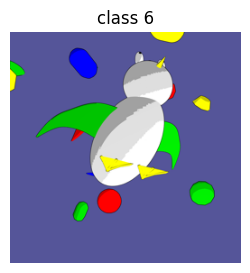

In [7]:
dataset = load_dataset(DATASET, transform=transform, **cfg_ds['load_kwargs'])
print(f'loaded: {len(dataset)} images, {dataset.num_classes} classes')

rng = np.random.default_rng(RANDOM_SEED)
stride = max(1, len(dataset) // 30)
focal_image = focal_class = focal_index = None
for i in range(0, len(dataset), stride):
    x_, y_ = dataset[i]
    x_dev = x_.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = model(x_dev).argmax(-1).item()
    if pred == int(y_):
        focal_image = x_dev.detach().requires_grad_(True)
        focal_class = pred
        focal_index = i
        break
if focal_image is None:
    raise RuntimeError(
        f'No correctly-classified sample found in first {len(dataset)//stride} '
        f'strided samples — probe accuracy may be too low. Re-train it with '
        f'more epochs or check dataset compatibility.'
    )

print(f'focal image: dataset index {focal_index}, class {focal_class}')
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(denormalize(focal_image, model)); ax.axis('off')
ax.set_title(f'class {focal_class}')
plt.show()

### Plain attribution (no concept conditioning) for reference

/home/claude/workspaces/zennit-crp/.claude/worktrees/agent-a84b2f416fce6a3e8/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


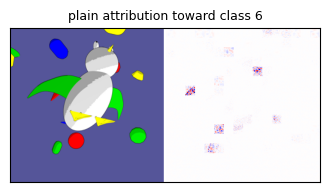

In [8]:
x_run = focal_image.detach().clone().requires_grad_(True)
res = attribution(x_run, [{'y': [focal_class]}], composite)
hm = res.heatmap[0]
if hm.dim() == 3 and hm.shape[0] == 3:
    hm = hm.sum(dim=0)
fig, ax = plt.subplots(1, 1, figsize=(4, 2))
panel(ax, denormalize(focal_image, model), hm.detach().cpu().numpy())
ax.set_title(f'plain attribution toward class {focal_class}', fontsize=9)
plt.show()

## 5. HeadConcept atlas at `MID_LAYER`

One panel per attention head at the chosen layer. Each panel shows
the input-space heatmap obtained by conditioning the backward on
that single head's `attn @ V` output. `score` in the title is the
per-head relevance summed over spatial tokens (excludes register
tokens by design).

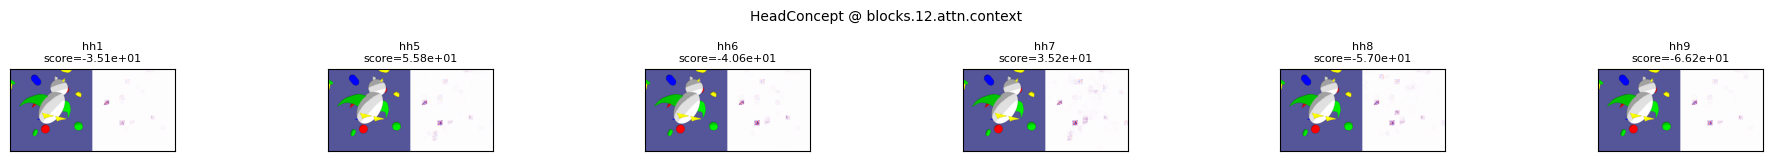

In [9]:
head_concept = HeadConcept(model)
head_layer = f'blocks.{MID_LAYER}.attn.{HeadConcept.LAYER_SUFFIX}'
with composite.context(model) as modified:
    head_concept = HeadConcept(modified)
fig = plot_concept_atlas(
    focal_image, model, attribution, composite,
    concept=head_concept, layer_name=head_layer,
    target_class=focal_class, top_k=TOP_K_CONCEPTS,
)
plt.show()

## 6. Q / K / V concept atlases at `MID_LAYER`

Same per-head granularity, but conditioned at the Q (post q_norm + RoPE),
K (post k_norm + RoPE), V (post per-head reshape) inputs to the
attention bilinears. These three rows show what each head's
**query / key / value** subspace contributes to the prediction.

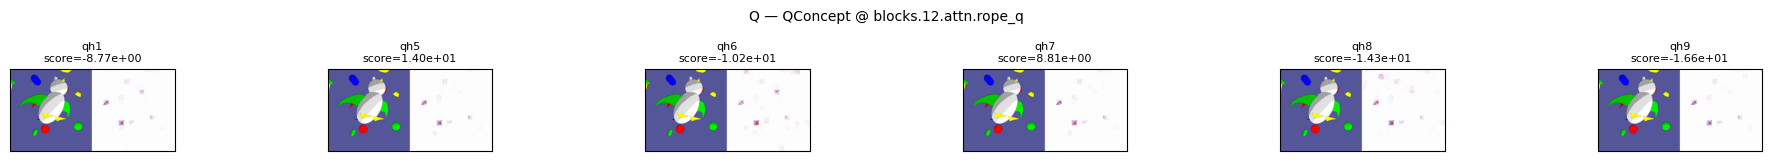

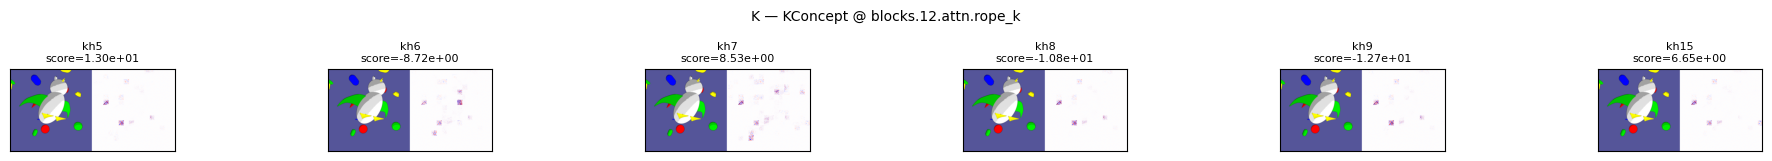

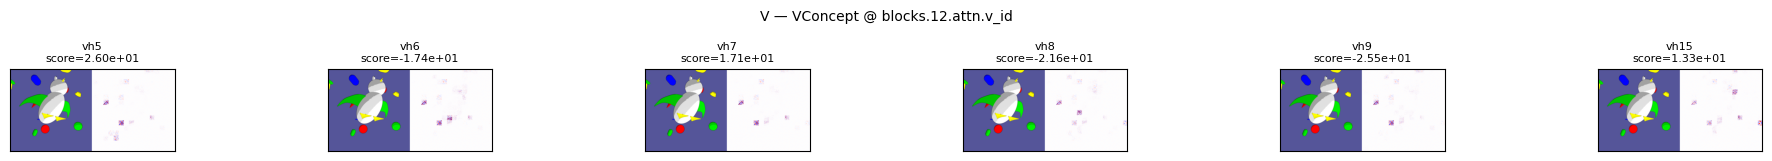

In [10]:
with composite.context(model) as modified:
    q_concept = QConcept(modified)
    k_concept = KConcept(modified)
    v_concept = VConcept(modified)
for concept_cls, concept in [('Q', q_concept), ('K', k_concept), ('V', v_concept)]:
    layer = f'blocks.{MID_LAYER}.attn.{type(concept).LAYER_SUFFIX}'
    fig = plot_concept_atlas(
        focal_image, model, attribution, composite,
        concept=concept, layer_name=layer,
        target_class=focal_class, top_k=TOP_K_CONCEPTS,
        title_prefix=concept_cls,
    )
    plt.show()

## 7. AttnOutputDimConcept top-K channel atlas

Conditioning at the **post-projection** residual contribution
(i.e. what the attention block writes into the residual stream).
Per-channel, spatial-aggregated. With `embed_dim = 1024` we
show only the top-K most relevant channels.

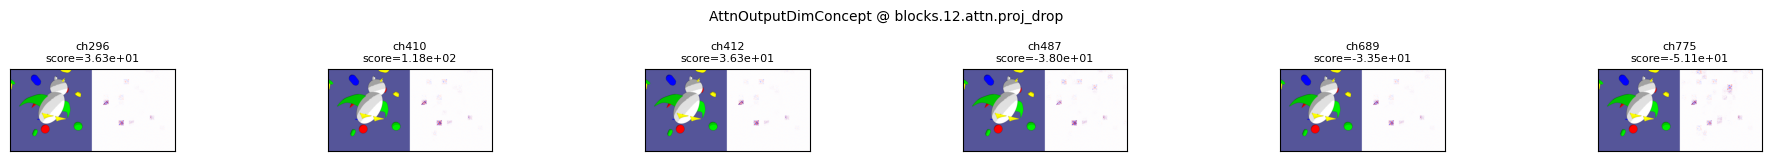

In [11]:
with composite.context(model) as modified:
    out_concept = AttnOutputDimConcept(modified)
out_layer = f'blocks.{MID_LAYER}.attn.{AttnOutputDimConcept.LAYER_SUFFIX}'
fig = plot_concept_atlas(
    focal_image, model, attribution, composite,
    concept=out_concept, layer_name=out_layer,
    target_class=focal_class, top_k=TOP_K_CONCEPTS,
)
plt.show()

## 8. RegisterTokenConcept atlas — cls + register tokens

DINOv3 prepends 5 prefix tokens (1 cls + 4 register). Each
carries global non-spatial signal — register tokens absorb
high-norm artifacts (Darcet et al. ICLR 2024,
arXiv:2309.16588). Per-token conditioning shows what each
prefix token contributes via the `proj_drop` residual stream.

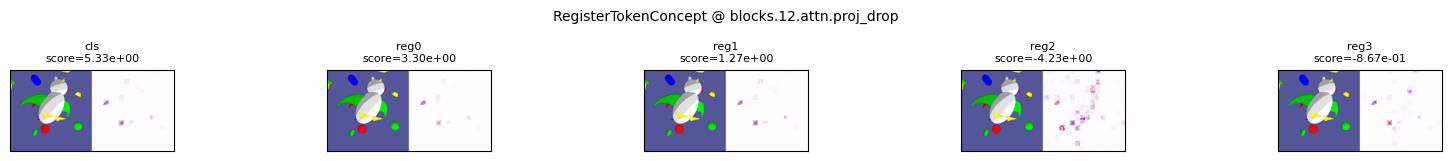

In [12]:
with composite.context(model) as modified:
    reg_concept = RegisterTokenConcept(modified)
reg_layer = f'blocks.{MID_LAYER}.attn.{RegisterTokenConcept.LAYER_SUFFIX}'
fig = plot_concept_atlas(
    focal_image, model, attribution, composite,
    concept=reg_concept, layer_name=reg_layer,
    target_class=focal_class,  # show ALL prefix tokens (5 cells)
)
plt.show()

## 9. Build FV index for reference-sample retrieval

Computes per-concept relevance over the first `FV_INDEX_SIZE` images
of the dataset and caches the per-concept top-N images for fast
retrieval. We index two granularities at the focal layer:

* `HeadConcept` at `MID_LAYER` — "images that maximally activate head k"
* `AttnOutputDimConcept` at `MID_LAYER` — "images that activate channel c"

Bump `FV_INDEX_SIZE` for richer retrieval; keep small for runnable
demos.

In [13]:
FV_CACHE_DIR = REPO_ROOT / 'data' / 'fv_cache_dinov3_unfolded'
FV_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# We need the model substituted (composite context entered) for the
# concepts to discover their layer dims correctly. We open the context
# once, build FV instances per concept type, and keep them alive while
# the index runs.
fv_results = {}
with composite.context(model) as modified:
    head_concept_fv = HeadConcept(modified)
    out_concept_fv  = AttnOutputDimConcept(modified)
    reg_concept_fv  = RegisterTokenConcept(modified)

    fv_specs = [
        ('head', head_concept_fv, f'blocks.{MID_LAYER}.attn.{HeadConcept.LAYER_SUFFIX}'),
        ('attnoutdim', out_concept_fv, f'blocks.{MID_LAYER}.attn.{AttnOutputDimConcept.LAYER_SUFFIX}'),
        ('register', reg_concept_fv, f'blocks.{MID_LAYER}.attn.{RegisterTokenConcept.LAYER_SUFFIX}'),
    ]
    for tag, concept, layer in fv_specs:
        cache_path = FV_CACHE_DIR / tag
        layer_map = {layer: concept}
        fv = FeatureVisualization(
            attribution=attribution, dataset=dataset,
            layer_map=layer_map, path=str(cache_path),
            device=DEVICE,
        )
        print(f'indexing {tag} on {layer} over {FV_INDEX_SIZE} images …')
        # NB: this uses the OUTSIDE composite, not `modified`, because
        # FeatureVisualization opens its own composite.context() per batch.
        # Concepts registered above still resolve (they keyed by layer name).
        fv.run(composite, 0, FV_INDEX_SIZE, batch_size=4, checkpoint=999)
        fv_results[tag] = (fv, concept, layer)
print('FV indexing complete')

indexing head on blocks.12.attn.context over 150 images …
Running Analysis...


  0%|          | 0/38 [00:00<?, ?it/s]

  5%|▌         | 2/38 [00:02<00:38,  1.07s/it]

  8%|▊         | 3/38 [00:03<00:47,  1.35s/it]

 11%|█         | 4/38 [00:05<00:55,  1.62s/it]

...

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 206.65it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 190.25it/s]

FV indexing complete


## 10. Reference samples per concept granularity

For each indexed concept type, fetch the top-N images that maximally
activate the top-K concept ids at the focal layer. The grid below
is rows × N: each row is one concept id, each column one of the top
reference images.

head: top-6 ids = [9, 8, 5, 6, 7, 1]


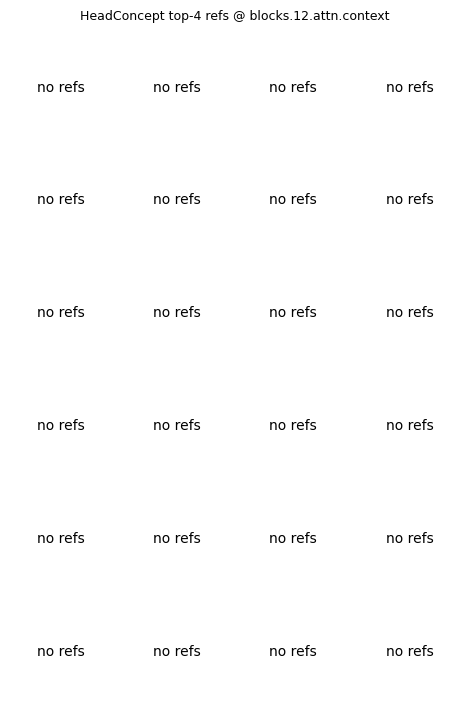

attnoutdim: top-6 ids = [410, 775, 487, 412, 296, 689]


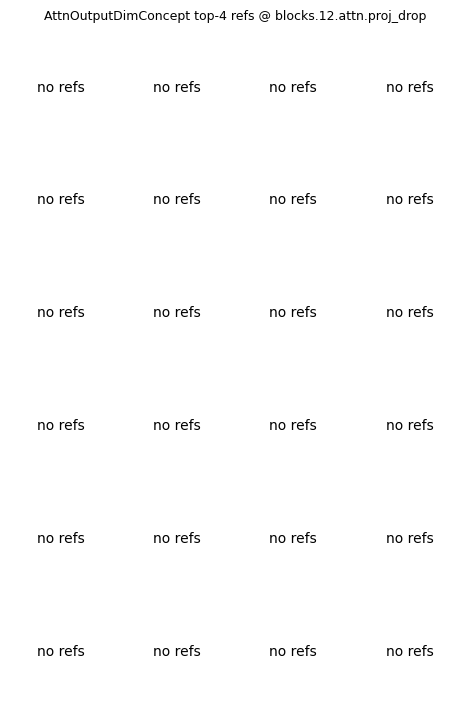

register: top-6 ids = [0, 3, 1, 2, 4]


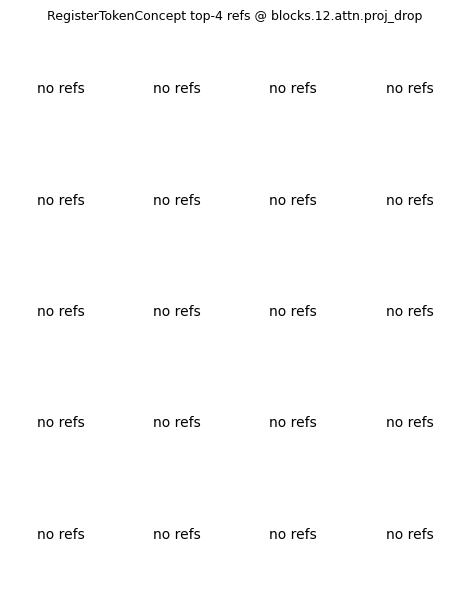

In [14]:
def show_references(fv, concept, layer, top_concept_ids, n_refs=N_REFS):
    # Extract per-concept top-r reference image indices via FV's API.
    n = len(top_concept_ids)
    fig, axes = plt.subplots(n, n_refs, figsize=(1.2 * n_refs, 1.2 * n))
    if n == 1: axes = axes.reshape(1, -1)
    for row, cid in enumerate(top_concept_ids):
        try:
            ref = fv.get_max_reference([cid], layer, mode='relevance',
                                       r_range=(0, n_refs), composite=composite,
                                       rf=False, plot_fn=imgify)
            imgs = ref[cid]
        except Exception as e:
            for ax in axes[row]: ax.text(0.5, 0.5, 'no refs', ha='center', va='center'); ax.axis('off')
            continue
        for ax, im in zip(axes[row], imgs[:n_refs]):
            ax.imshow(im); ax.axis('off')
        axes[row, 0].set_ylabel(label_id(concept, cid), fontsize=8,
                                rotation=0, ha='right', va='center')
    fig.suptitle(f'{type(concept).__name__} top-{n_refs} refs @ {layer}', fontsize=9)
    plt.tight_layout()
    plt.show()

# For each indexed concept, pick the top-K most relevant ids on the focal
# image and show the reference samples.
for tag, (fv, concept, layer) in fv_results.items():
    scores = per_concept_scores(
        attribution, composite, focal_image, layer, concept, focal_class,
    )
    top_ids_idx = torch.argsort(scores.abs(), descending=True)[:TOP_K_CONCEPTS].cpu().tolist()
    all_ids = enumerate_ids(concept, layer)
    top_ids = [all_ids[i] for i in top_ids_idx]
    print(f'{tag}: top-{TOP_K_CONCEPTS} ids = {top_ids}')
    show_references(fv, concept, layer, top_ids, n_refs=N_REFS)

## 11. Conditional propagation cascade

Walk attention layers from deep to shallow. At each layer, condition
on the top-K most relevant concepts at every deeper layer already
visited (cumulative conditioning), then pick this layer's top-K.
Renders one row per layer; columns are the kept concepts. Reading
top-to-bottom traces how the model's attention concept selection
narrows as we descend toward the input.

Configurable: `CASCADE_LAYERS` (set in section 2). Default uses
HeadConcept; swap in QConcept / VConcept etc. by changing the
concept argument.

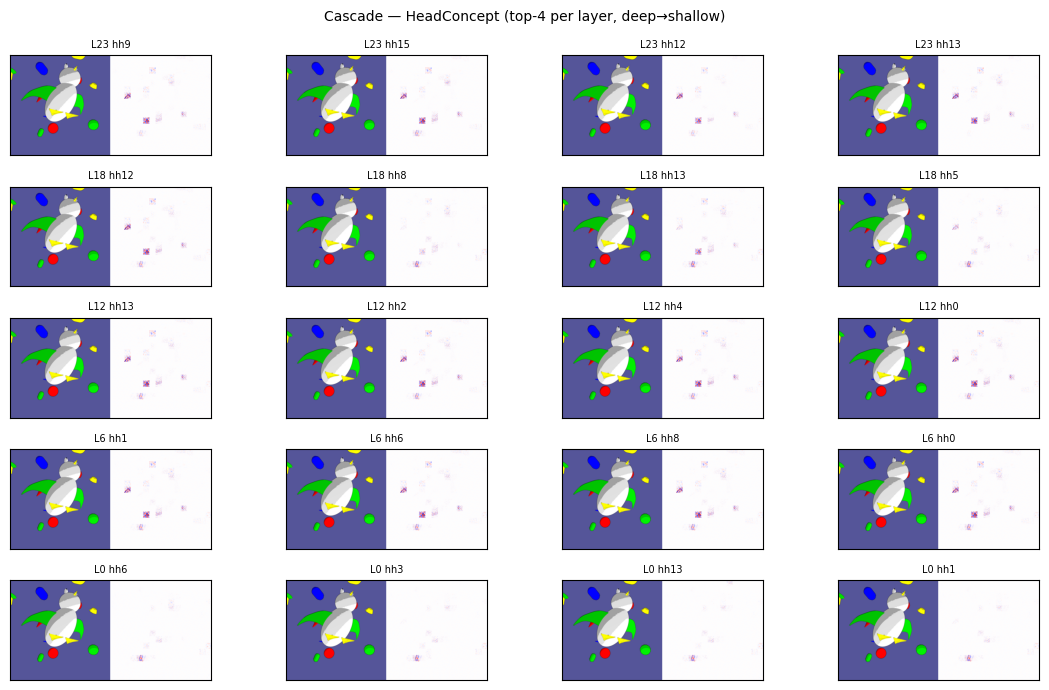

selected concepts per layer (deep → shallow):
  blocks.23.attn.context  →  heads [9, 15, 12, 13]
  blocks.18.attn.context  →  heads [12, 8, 13, 5]
  blocks.12.attn.context  →  heads [13, 2, 4, 0]
  blocks. 6.attn.context  →  heads [1, 6, 8, 0]
  blocks. 0.attn.context  →  heads [6, 3, 13, 1]


In [15]:
with composite.context(model) as modified:
    cascade_concept = HeadConcept(modified)
fig, selected = plot_cascade(
    focal_image, model, attribution, composite,
    concept=cascade_concept,
    layer_indices=CASCADE_LAYERS,
    target_class=focal_class,
    top_k=4,
)
plt.show()
print('selected concepts per layer (deep → shallow):')
for li in CASCADE_LAYERS:
    print(f'  blocks.{li:>2}.attn.context  →  heads {selected.get(li)}')

## 12. Notes & next steps

* **Magnitude regime.** With AlphaBeta(0.5, 0.5) the input |R|_max
  is O(10²) and conservation is within a few × the target logit
  (vs ~10²² magnitudes under the standard `2y+ε` rule — see
  `RESEARCH_NOTES.md` Entry 6).
* **Spatial vs prefix tokens.** All concepts here cleanly separate
  the two: the per-head + AttnOutputDim concepts only see spatial
  patch tokens; `RegisterTokenConcept` only sees the prefix
  (cls + register) tokens. Neither concept class mixes them.
* **`AttnWeightConcept` is intentionally absent.** Softmax weights
  have no fixed semantic per neuron (the same cell combines
  different concepts for different inputs), so reference-sample
  retrieval would be uninformative. The `attn.softmax` submodule
  is still hookable for direct attention-map inspection via
  `record_layer=['blocks.{i}.attn.softmax']` — useful for K/Q
  relation analysis but not for concept identification.
* **FV indexing scope.** This notebook indexes 200 images for
  speed. For production analysis (e.g. paper-grade concept
  atlases), bump `FV_INDEX_SIZE` to the full dataset and
  re-run section 9 — the cache is persisted, so subsequent
  sections re-use it.
* **Other layers.** Re-run sections 5-8 with `MID_LAYER` set to
  e.g. 0 (early — likely texture concepts) or 23 (late — likely
  object-semantic concepts) to compare across depth.
* **Other concepts in cascade.** Section 11 uses `HeadConcept`;
  swap to `QConcept` / `KConcept` / `VConcept` to compare which
  attention sub-axis dominates the model's reasoning.